In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import ast

####Solar Potential

In [21]:
df_usa = pd.read_csv('usa_solar_potential.csv')

In [22]:
df_usa.shape

(9314, 10)

In [23]:
df_usa.head(5)

,state_abbr,state_fips,county_fips,sector_abbr,energy_value_us_dollars_per_kwh,percent_customers_with_nonzero_sys_size,avg_roof_sqft_customers_with_nonzero_sys_size,avg_roof_sqft_total,hourly_capacity_factor,hourly_capacity_factor_scalar
0,AL,1,1,com,0.0911,0.99,2473.0,4196.0,"[0,0,0,0,0,0,0,799,4190,6338,7315,7366,7049,65...",10000
1,AL,1,1,ind,0.1143,1.00,4196.0,4196.0,"[0,0,0,0,0,0,0,799,4190,6338,7315,7366,7049,65...",10000
2,AL,1,1,res,0.1037,0.54,415.0,349.0,"[0,0,0,0,0,0,0,799,4190,6338,7315,7366,7049,65...",10000
3,AL,1,3,com,0.0743,0.56,2596.0,3973.0,"[0,0,0,0,0,0,0,674,1976,2935,3579,1372,4828,55...",10000
4,AL,1,3,ind,0.0715,0.34,6109.0,3973.0,"[0,0,0,0,0,0,0,674,1976,2935,3579,1372,4828,55...",10000


In [24]:
df_usa.dtypes

,0
state_abbr,object
state_fips,int64
county_fips,int64
sector_abbr,object
energy_value_us_dollars_per_kwh,object
percent_customers_with_nonzero_sys_size,float64
avg_roof_sqft_customers_with_nonzero_sys_size,float64
avg_roof_sqft_total,float64
hourly_capacity_factor,object
hourly_capacity_factor_scalar,int64


In [25]:
df_usa.isna().sum()

,0
state_abbr,0
state_fips,0
county_fips,0
sector_abbr,0
energy_value_us_dollars_per_kwh,2351
percent_customers_with_nonzero_sys_size,0
avg_roof_sqft_customers_with_nonzero_sys_size,2351
avg_roof_sqft_total,0
hourly_capacity_factor,0
hourly_capacity_factor_scalar,0


In [26]:
df_usa["energy_value_us_dollars_per_kwh"] = pd.to_numeric(
    df_usa["energy_value_us_dollars_per_kwh"],
    errors="coerce"
)

In [27]:
def get_capacity_array(row):
    try:
        arr = np.array(ast.literal_eval(row["hourly_capacity_factor"]))
        return arr / float(row["hourly_capacity_factor_scalar"])
    except:
        return np.nan

df_usa["hourly_cf_array"] = df_usa.apply(get_capacity_array, axis=1)

In [28]:
df_usa.head(2)

,state_abbr,state_fips,county_fips,sector_abbr,energy_value_us_dollars_per_kwh,percent_customers_with_nonzero_sys_size,avg_roof_sqft_customers_with_nonzero_sys_size,avg_roof_sqft_total,hourly_capacity_factor,hourly_capacity_factor_scalar,hourly_cf_array
0,AL,1,1,com,0.0911,0.99,2473.0,4196.0,"[0,0,0,0,0,0,0,799,4190,6338,7315,7366,7049,65...",10000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0799, 0...."
1,AL,1,1,ind,0.1143,1.00,4196.0,4196.0,"[0,0,0,0,0,0,0,799,4190,6338,7315,7366,7049,65...",10000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0799, 0...."


In [29]:
df_usa["avg_solar_potential"] = df_usa["hourly_cf_array"].apply(
    lambda x: np.mean(x) if isinstance(x, np.ndarray) else np.nan
)

In [30]:
df_usa.head(2)

,state_abbr,state_fips,county_fips,sector_abbr,energy_value_us_dollars_per_kwh,percent_customers_with_nonzero_sys_size,avg_roof_sqft_customers_with_nonzero_sys_size,avg_roof_sqft_total,hourly_capacity_factor,hourly_capacity_factor_scalar,hourly_cf_array,avg_solar_potential
0,AL,1,1,com,0.0911,0.99,2473.0,4196.0,"[0,0,0,0,0,0,0,799,4190,6338,7315,7366,7049,65...",10000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0799, 0....",0.170006
1,AL,1,1,ind,0.1143,1.00,4196.0,4196.0,"[0,0,0,0,0,0,0,799,4190,6338,7315,7366,7049,65...",10000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0799, 0....",0.170006


In [31]:
df_res = df_usa[df_usa["sector_abbr"] == "res"]

In [32]:
state_df = df_res.groupby(["state_abbr", "sector_abbr"]).agg({
    "percent_customers_with_nonzero_sys_size": "mean",
    "energy_value_us_dollars_per_kwh": "mean",
    "avg_roof_sqft_total": "mean",
    "avg_solar_potential": "mean"
}).reset_index()

In [33]:
state_df.sort_values(
    "avg_solar_potential",
    ascending=False
).head(10)

,state_abbr,sector_abbr,percent_customers_with_nonzero_sys_size,energy_value_us_dollars_per_kwh,avg_roof_sqft_total,avg_solar_potential
30,NM,res,0.686364,0.103443,331.000000,0.212553
2,AZ,res,0.983333,0.100753,326.533333,0.211909
31,NV,res,0.761176,0.092779,445.176471,0.203933
4,CO,res,0.657969,0.104822,412.062500,0.193291
42,UT,res,1.000000,0.063464,379.068966,0.192628
3,CA,res,0.955172,0.147648,419.258621,0.190869
14,KS,res,0.735429,0.105001,507.152381,0.180914
41,TX,res,0.544803,0.113887,519.948819,0.179192
48,WY,res,0.289565,0.103200,467.521739,0.179154
34,OK,res,0.096364,0.103830,431.402597,0.177382


In [34]:
top_solar = state_df.sort_values(
    "avg_solar_potential", ascending=False
).head(5)

print(top_solar[[
    "state_abbr",
    "avg_solar_potential",
    "percent_customers_with_nonzero_sys_size"
]])

   state_abbr  avg_solar_potential  percent_customers_with_nonzero_sys_size
30         NM             0.212553                                 0.686364
2          AZ             0.211909                                 0.983333
31         NV             0.203933                                 0.761176
4          CO             0.193291                                 0.657969
42         UT             0.192628                                 1.000000


###Solar Installation Costs

In [35]:
df_berk = pd.read_csv('usa_solar_costs.csv')

/tmp/ipykernel_2488/1581667334.py:1: DtypeWarning: Columns (1,2,3,11,15,16,18,28,29,31,32,34,35,38,39,40,53,54,56,57,59,60,74,75,79,80) have mixed types. Specify dtype option on import or set low_memory=False.
  df_berk = pd.read_csv('usa_solar_costs.csv')


In [36]:
#Only using data from 2022

df_berk["installation_date"] = pd.to_datetime(df_berk["installation_date"])

df_berk = df_berk[
    (df_berk["installation_date"].dt.year >= 2022)
]

In [37]:
df_berk.shape

(1102227, 81)

In [38]:
#missing values are coded as -1 so need to handle that
df_berk = df_berk.replace(-1, np.nan)

In [39]:
df_berk["price_per_kw"] = (
    df_berk["total_installed_price"] / df_berk["PV_system_size_DC"]
)

In [40]:
#only looking at residential data since we have solar potential data for residential segment
df_res = df_berk[df_berk["customer_segment"].str.contains("RES")]

In [41]:
df_berk_clean = df_berk[
    (df_berk["price_per_kw"].notna()) &
    (df_berk["price_per_kw"] > 0)
]

In [42]:
# df_berk_clean = df_berk[
#     (df_berk["price_per_kw"].notna()) &
#     (df_berk["price_per_kw"] > 0)
# ]

states_with_price = df_berk["state"].unique()

print(sorted(states_with_price))

['AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'IL', 'MA', 'MD', 'ME', 'MN', 'NH', 'NJ', 'NM', 'NY', 'OH', 'OR', 'RI', 'TX', 'UT', 'VT', 'WI']


In [43]:
state_res = df_berk.groupby("state").agg({
    "price_per_kw": "median",
    "rebate_or_grant": "median",
    "total_installed_price": "median",
    "PV_system_size_DC": "count"   # proxy for adoption
}).rename(columns={
    "PV_system_size_DC": "num_installations"
}).reset_index()

In [44]:
state_res.head(5)

,state,price_per_kw,rebate_or_grant,total_installed_price,num_installations
0,AZ,4083.932507,0.0,34816.28,98603
1,CA,4090.550636,0.0,24940.00,575000
2,CO,4337.881279,NaN,27098.54,34631
3,CT,4197.761194,0.0,32978.40,7451
4,DC,NaN,NaN,NaN,7527


In [45]:
top_state_low_prices = state_res.sort_values(
    "price_per_kw", ascending=True
).head(5)

In [46]:
top_state_low_prices

,state,price_per_kw,rebate_or_grant,total_installed_price,num_installations
12,NH,3245.471919,1000.0,34061.000,1811
22,WI,3556.925873,500.0,31143.285,9128
17,OR,3713.456890,0.0,35096.000,1611
8,MA,3797.600305,0.0,35836.000,14904
11,MN,3830.238095,NaN,33000.000,5857


In [47]:
top_state = state_res.sort_values(
    "num_installations", ascending=False
).head(5)

###USA Household Income

In [48]:
df_usa_income = pd.read_csv('usa_household_income.csv', skiprows= 4, skipfooter=8)

/tmp/ipykernel_2488/3162901382.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  df_usa_income = pd.read_csv('usa_household_income.csv', skiprows= 4, skipfooter=8)


In [49]:
df_usa_income.head(1)

,State,FIPS,Value (Dollars),Rank within US (of 52 states)
0,United States,0,"78,538",NaN


In [50]:
df_usa_income.dtypes

,0
State,object
FIPS,int64
Value (Dollars),object
Rank within US (of 52 states),float64


In [51]:
df_usa_income.columns = (
    df_usa_income.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

print(df_usa_income.columns)

Index(['state', 'fips', 'value_(dollars)', 'rank_within_us_(of_52_states)'], dtype='object')


In [52]:
##remove USA and Puerto Rico
df_usa_income = df_usa_income[
    ~df_usa_income["state"].isin(["United States", "Puerto Rico"])
]

In [53]:
# then
df_usa_income["median_income"] = pd.to_numeric(
    df_usa_income["value_(dollars)"].astype(str).str.replace(",", ""),
    errors="coerce"
)

In [54]:
df_usa_income.head(5)

,state,fips,value_(dollars),rank_within_us_(of_52_states),median_income
2,Mississippi,28000,"54,915",51.0,54915
3,West Virginia,54000,"57,917",50.0,57917
4,Arkansas,5000,"58,773",49.0,58773
5,Louisiana,22000,"60,023",48.0,60023
6,Alabama,1000,"62,027",47.0,62027


In [55]:
top_median_income = df_usa_income.sort_values(
    "median_income", ascending=False
).head(6)

In [56]:
top_median_income

,state,fips,value_(dollars),rank_within_us_(of_52_states),median_income
52,District of Columbia,11001,"106,287",1.0,106287
51,Maryland,24000,"101,652",2.0,101652
50,Massachusetts,25000,"101,341",3.0,101341
49,New Jersey,34000,"101,050",4.0,101050
48,Hawaii,15000,"98,317",5.0,98317
47,California,6000,"96,334",6.0,96334


In [57]:
df_state = pd.read_csv('usa_state.csv')

In [58]:
df_state.head(2)

,state,state_abbr
0,Alabama,AL
1,Alaska,AK


In [59]:
df_usa_income = df_usa_income.merge(
    df_state[["state", "state_abbr"]],
    on="state",
    how="left"
)

In [60]:
df_usa_income.head(2)

,state,fips,value_(dollars),rank_within_us_(of_52_states),median_income,state_abbr
0,Mississippi,28000,"54,915",51.0,54915,MS
1,West Virginia,54000,"57,917",50.0,57917,WV


In [61]:
final_us_df = df_usa_income[["state", "state_abbr", "median_income"]] \
    .merge(
        state_res,
        left_on="state_abbr",
        right_on="state",
        how="left"
    )

In [62]:
final_us_df

,state_x,state_abbr,median_income,state_y,price_per_kw,rebate_or_grant,total_installed_price,num_installations
0,Mississippi,MS,54915,NaN,NaN,NaN,NaN,NaN
1,West Virginia,WV,57917,NaN,NaN,NaN,NaN,NaN
2,Arkansas,AR,58773,NaN,NaN,NaN,NaN,NaN
3,Louisiana,LA,60023,NaN,NaN,NaN,NaN,NaN
4,Alabama,AL,62027,NaN,NaN,NaN,NaN,NaN
5,New Mexico,NM,62125,NM,4598.076923,NaN,30800.000,18694.0
6,Kentucky,KY,62417,NaN,NaN,NaN,NaN,NaN
7,Oklahoma,OK,63603,NaN,NaN,NaN,NaN,NaN
8,South Carolina,SC,66818,NaN,NaN,NaN,NaN,NaN
9,Tennessee,TN,67097,NaN,NaN,NaN,NaN,NaN


In [63]:
final_us_df["state_abbr"] = (
    final_us_df["state_abbr"]
    .astype(str)
    .str.strip()
    .str.upper()
)

state_df["state_abbr"] = (
    state_df["state_abbr"]
    .astype(str)
    .str.strip()
    .str.upper()
)

In [64]:
left_keys = set(final_us_df["state_abbr"].dropna().unique())
right_keys = set(state_df["state_abbr"].dropna().unique())

print("Only in income/final table:", sorted(left_keys - right_keys))
print("Only in state_res:", sorted(right_keys - left_keys))

Only in income/final table: ['AK', 'HI']
Only in state_res: []


In [65]:
final_usa_df = final_us_df[["state_x", "state_abbr", "median_income", "price_per_kw", "num_installations"]].merge(
    state_df[["state_abbr","avg_solar_potential"]],
    on="state_abbr",
    how="left"
)

In [66]:
final_usa_df.columns

Index(['state_x', 'state_abbr', 'median_income', 'price_per_kw',
       'num_installations', 'avg_solar_potential'],
      dtype='object')

In [67]:
final_usa_df = final_usa_df[
    final_usa_df["price_per_kw"].notna()
]
final_usa_df

,state_x,state_abbr,median_income,price_per_kw,num_installations,avg_solar_potential
5,New Mexico,NM,62125,4598.076923,18694.0,0.212553
16,Florida,FL,71711,4100.000000,5735.0,0.171230
26,Wisconsin,WI,75670,3556.925873,9128.0,0.152176
29,Texas,TX,76292,4000.000000,112843.0,0.179192
30,Arizona,AZ,76872,4083.932507,98603.0,0.211909
32,Oregon,OR,80426,3713.456890,1611.0,0.158017
34,Delaware,DE,82855,4027.475607,2865.0,0.163249
35,New York,NY,84578,3938.243110,47731.0,0.147341
36,Rhode Island,RI,86372,4207.142857,1352.0,0.156357
37,Minnesota,MN,87556,3830.238095,5857.0,0.152686


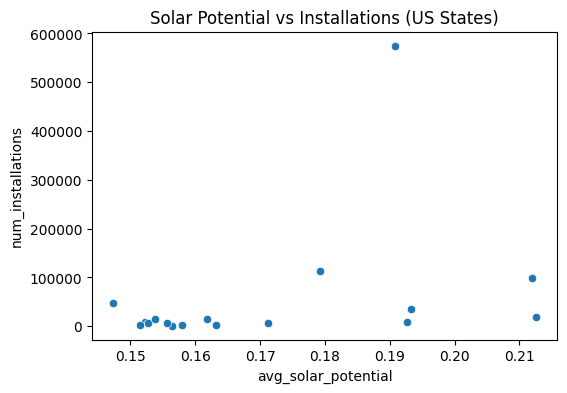

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=final_usa_df,
    x="avg_solar_potential",
    y="num_installations",
)

plt.title("Solar Potential vs Installations (US States)")
plt.show()

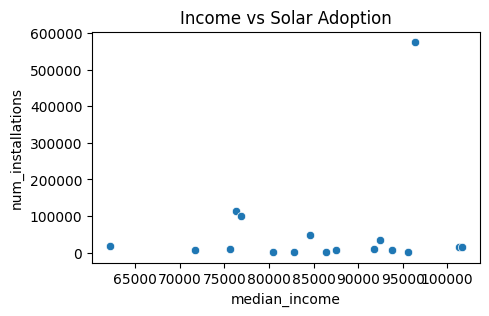

In [69]:
plt.figure(figsize=(5,3))

sns.scatterplot(
    data=final_usa_df,
    x="median_income",
    y="num_installations"
)

plt.title("Income vs Solar Adoption")
plt.show()

/tmp/ipykernel_2488/3387524588.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = final_usa_df.groupby("income_bin")["num_installations"].mean().reset_index()


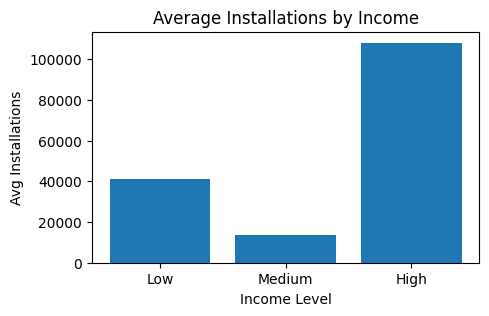

In [70]:
final_usa_df["income_bin"] = pd.qcut(
    final_usa_df["median_income"],
    q=3,
    labels=["Low", "Medium", "High"]
)

grouped = final_usa_df.groupby("income_bin")["num_installations"].mean().reset_index()

plt.figure(figsize=(5,3))
plt.bar(grouped["income_bin"], grouped["num_installations"])
plt.title("Average Installations by Income")
plt.xlabel("Income Level")
plt.ylabel("Avg Installations")
plt.show()

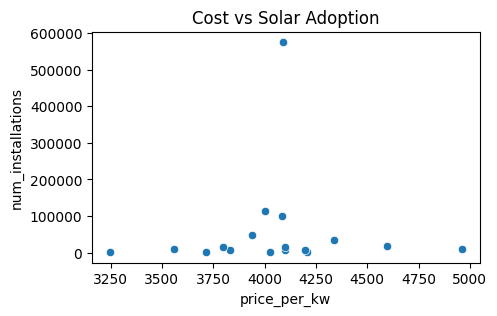

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))

sns.scatterplot(
    data=final_usa_df,
    x="price_per_kw",
    y="num_installations"
)

plt.title("Cost vs Solar Adoption")
plt.show()

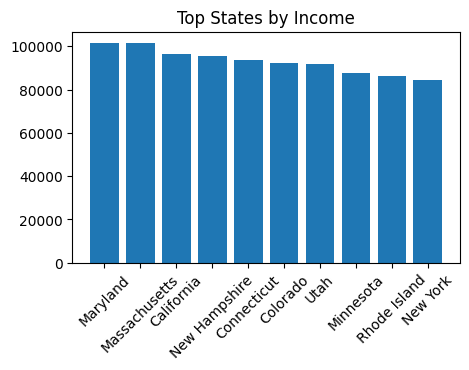

In [73]:
top_income = final_usa_df.sort_values("median_income", ascending=False).head(10)

plt.figure(figsize=(5,3))
plt.bar(top_income["state_x"], top_income["median_income"])
plt.xticks(rotation=45)
plt.title("Top States by Income")
plt.show()

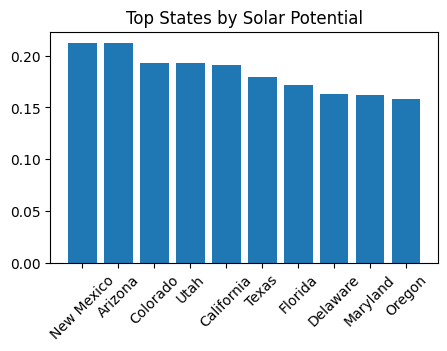

In [75]:
top_potential = final_usa_df.sort_values("avg_solar_potential", ascending=False).head(10)

plt.figure(figsize=(5,3))
plt.bar(top_potential["state_x"], top_potential["avg_solar_potential"])
plt.xticks(rotation=45)
plt.title("Top States by Solar Potential")
plt.show()

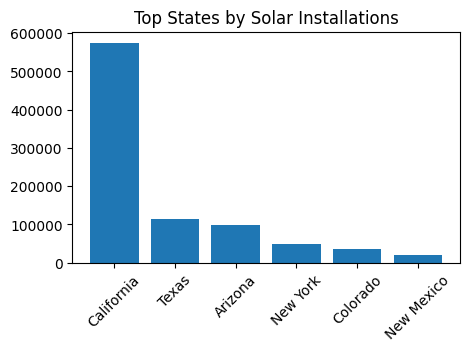

In [76]:
top_installs = final_usa_df.sort_values("num_installations", ascending=False).head(6)

plt.figure(figsize=(5,3))
plt.bar(top_installs["state_x"], top_installs["num_installations"])
plt.xticks(rotation=45)
plt.title("Top States by Solar Installations")
plt.show()

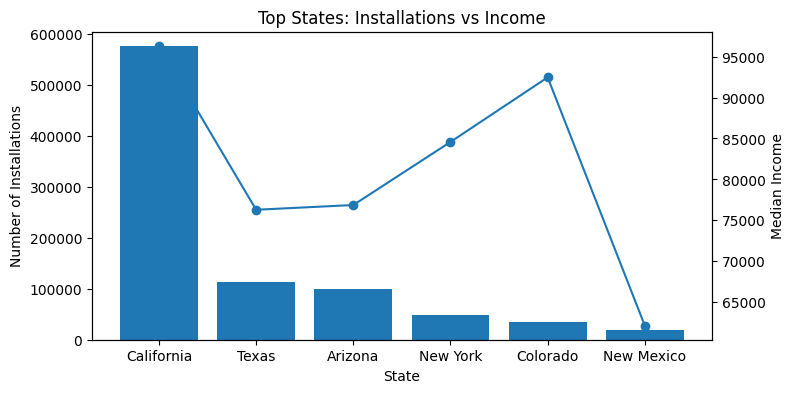

In [77]:
fig, ax1 = plt.subplots(figsize=(8,4))

# Bar chart (installations)
ax1.bar(top_installs["state_x"], top_installs["num_installations"])
ax1.set_xlabel("State")
ax1.set_ylabel("Number of Installations")

# Line chart (income)
ax2 = ax1.twinx()
ax2.plot(top_installs["state_x"], top_installs["median_income"], marker='o')
ax2.set_ylabel("Median Income")

plt.xticks(rotation=45)
plt.title("Top States: Installations vs Income")

plt.show()

In [78]:
df_res["year_month"] = df_res["installation_date"].dt.to_period("Y").astype(str)

/tmp/ipykernel_2488/2664772296.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res["year_month"] = df_res["installation_date"].dt.to_period("Y").astype(str)


In [79]:
monthly_trend = df_res.groupby("year_month")["price_per_kw"].mean().reset_index()

In [80]:
monthly_trend = df_res.groupby("year_month")["PV_system_size_DC"].mean().reset_index()

In [81]:
monthly_trend = df_res.groupby("year_month").agg({
    "price_per_kw": "mean",
    "PV_system_size_DC": "sum"   # better than mean for volume
}).reset_index()

In [82]:
monthly_trend.head(1)

,year_month,price_per_kw,PV_system_size_DC
0,2022,4275.691224,4.264705e+06


####End